In [1]:
# Run once to install dependencies
%pip install anthropic python-docx

Note: you may need to restart the kernel to use updated packages.


In [9]:
import os
import sys
sys.path.append('./coeqwalpackage')

from getpass import getpass
import json, shutil
from IPython.display import Image, display
from coeqwalpackage.prompts import build_prompt, extract_plot_type
from coeqwalpackage.llm_utils import analyze_plot, generate_summary
from coeqwalpackage import cqwlutils as cu

# Prompt for API key if not set in environment
if not os.environ.get("ANTHROPIC_API_KEY"):
    os.environ["ANTHROPIC_API_KEY"] = getpass("Enter Anthropic API key: ")

In [3]:
CtrlFile = 'CalSim3DataExtractionInitFile_v4.xlsx'
CtrlTab = 'Init'

ScenarioListFile, ScenarioListTab, ScenarioListPath, DVDssNamesOutPath, SVDssNamesOutPath, ScenarioIndicesOutPath, DssDirsOutPath, VarListPath, VarListFile, VarListTab, VarOutPath, DataOutPath, ConvertDataOutPath, ExtractionSubPath, DemandDeliverySubPath, ModelSubPath, GroupDataDirPath, ScenarioDir, *_rest = cu.read_init_file(CtrlFile, CtrlTab)

scenario_labels = cu.build_scenario_labels_from_listing(ScenarioListPath, ScenarioListFile, ScenarioListTab)

plots_root = os.path.join(GroupDataDirPath, "plots_output")
if not os.path.isdir(plots_root):
    raise FileNotFoundError(f"Plots directory not found: {plots_root}\nRun Plotting.ipynb first to generate plots.")

available_sets = sorted([d for d in os.listdir(plots_root) if os.path.isdir(os.path.join(plots_root, d))])
if not available_sets:
    raise FileNotFoundError(f"No scenario set folders found in: {plots_root}")

print("Available scenario sets:")
for i, s in enumerate(available_sets):
    print(f"  [{i}] {s}")

Available scenario sets:
  [0] s20_s11_s21_s23_s24
  [1] s20_s25_s26_s27_s28
  [2] s20_s29_s30_s31_s32_s33
  [3] s20_s39_s40_s41_s42
  [4] s20_s44_s45_s65


In [4]:
# Select a set (change index to pick a different one)
SET_INDEX = 0
if SET_INDEX >= len(available_sets):
    raise IndexError(f"SET_INDEX={SET_INDEX} but only {len(available_sets)} sets available [0-{len(available_sets)-1}]")

set_name = available_sets[SET_INDEX]
plots_base = os.path.join(plots_root, set_name)

try:
    _ids = [int(x.lstrip("s")) for x in set_name.split("_")]
except ValueError:
    raise ValueError(f"Cannot parse scenario IDs from directory name: '{set_name}'. Expected format: s##_s##_...")

baseline = _ids[0]
compare = _ids[1:]
all_scenarios = [baseline] + compare

print(f"Selected: {set_name}")
print(f"Baseline: s{baseline:04d} — {scenario_labels.get(baseline, '?')}")
for s in compare:
    print(f"Compare: s{s:04d} — {scenario_labels.get(s, '?')}")

Selected: s20_s11_s21_s23_s24
Baseline: s0020 — s0020_DCRadjBL_2020LU_wTUCP
Compare: s0011 — s0011_adjBL_wTUCP
Compare: s0021 — s0021_DCRadjBL_2020LU_woTUCP
Compare: s0023 — s0023_USBR24Alt2V1_adjBL_2020LU_woTUCP
Compare: s0024 — s0024_USBR24Alt2V1_adjHist_2020LU_wTUCP


## Test: Single Image LLM Analysis

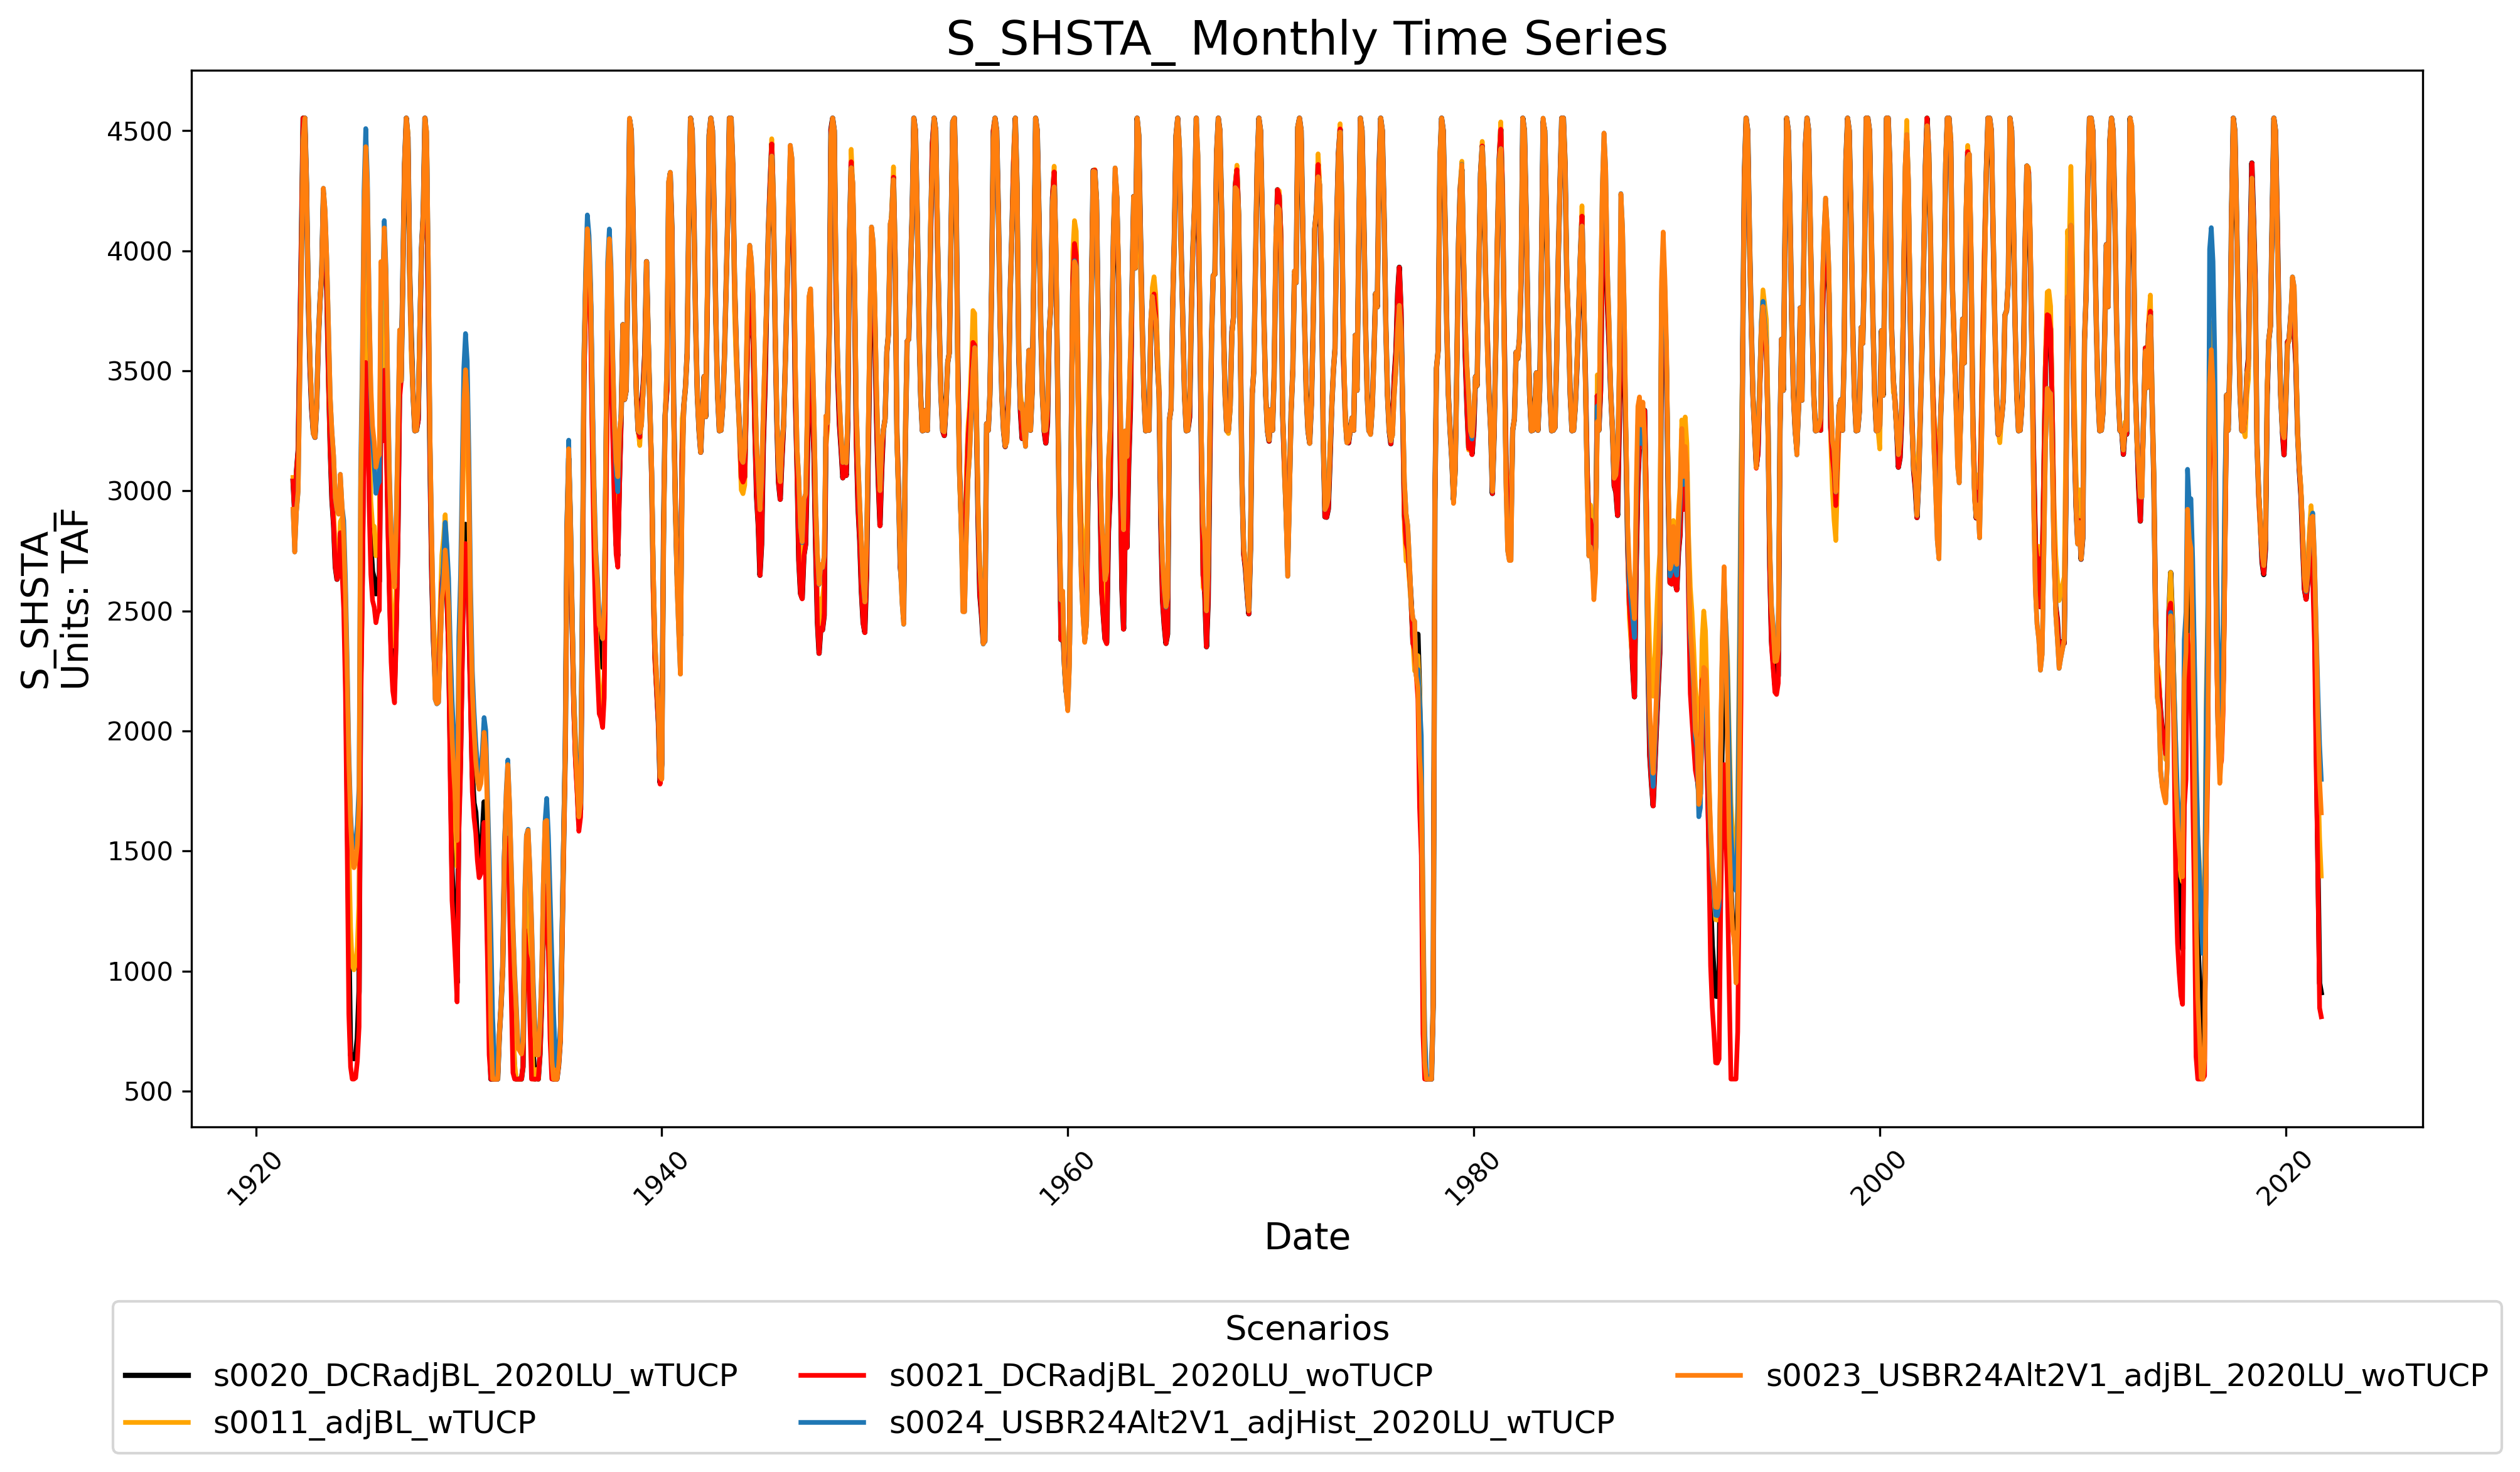

Plot type: mon_ts
Prompt:
This is a monthly time series of Shasta Reservoir Storage (TAF). Focus on periods where scenarios clearly diverge and any notable drought or peak events.

Scenarios: s0020, s0011, s0021, s0023, s0024. Baseline: s0020.

Respond in around 2-4 concise, gramatically accurate sentences - no run on sentences! State only empirical, observable findings — no speculation or interpretation. If scenarios are visually indistinguishable or largely overlap, say so explicitly.

LLM Response:
The scenarios are visually indistinguishable and largely overlap throughout the entire time series from 1920 to 2020. All scenarios show identical patterns during major drought periods, including severe drops to around 500 TAF in the mid-1930s, late 1970s, early 1990s, and mid-2010s. Peak storage levels consistently reach approximately 4500 TAF across all scenarios during wet periods. The baseline scenario s0020 does not diverge noticeably from any of the other four scenarios.
Saved to: .

In [10]:
TEST_PLOT = ("mon_ts", "S_SHSTA__mon_ts.png", "Shasta Reservoir Storage (TAF)")
# TEST_PLOT = ("moy_avg", "S_SHSTA__moy_all.png", "Shasta Reservoir Storage (TAF)")
# TEST_PLOT = ("exceedance", "S_SHSTA__exceed_all.png", "Shasta Reservoir Storage (TAF)")
# TEST_PLOT = ("ann_exceed", "S_SHSTA__ann_exceed_apr.png", "Shasta Reservoir Storage (TAF)")
# TEST_PLOT = ("moy_avg", "DEL_CVP_PAG_N_moy_all.png", "CVP Ag Deliveries NOD (TAF)")
# TEST_PLOT = ("exceedance", "X2_PRV_KM__exceed_dry.png", "X2 Salinity Position (KM)")

scenario_ctx = None

subdir, filename, var_label = TEST_PLOT
test_image = os.path.join(plots_base, subdir, filename)
assert os.path.isfile(test_image), f"Not found: {test_image}"

display(Image(filename=test_image, width=700))

plot_type = extract_plot_type(filename)
scenario_names_str = ", ".join([f"s{s:04d}" for s in all_scenarios])
baseline_str = f"s{baseline:04d}"

prompt = build_prompt(plot_type, var_label, scenario_names_str, baseline_str,
                      scenario_context=scenario_ctx)
print(f"Plot type: {plot_type}")
print(f"Prompt:\n{prompt}\n")

observation = analyze_plot(test_image, prompt, max_tokens=200)
print("LLM Response:")
print(observation)

output_dir = os.path.join("..", "outputs", "llm_task", set_name, subdir)
os.makedirs(output_dir, exist_ok=True)
shutil.copy2(test_image, os.path.join(output_dir, filename))

obs_file = os.path.join(output_dir, filename.replace(".png", ".json"))
with open(obs_file, "w") as f:
    json.dump({"filename": filename, "plot_type": plot_type, "var_label": var_label, "prompt": prompt, "observation": observation}, f, indent=2)
print(f"Saved to: {output_dir}")